In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import easyocr

In [100]:
METER_LOWER = np.array([0, 0, 100])
METER_UPPER = np.array([179, 255, 230])

KERNEL_SIZE = 10

OPEN_ITERATIONS = 0
CLOSE_ITERATIONS = 1

def crop_meter(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    bgr = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    
    mask = cv2.inRange(hsv, METER_LOWER, METER_UPPER)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (KERNEL_SIZE, KERNEL_SIZE))
    
    if OPEN_ITERATIONS > 0:
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=OPEN_ITERATIONS)
    
    if CLOSE_ITERATIONS > 0:
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=CLOSE_ITERATIONS)
    
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return img

    c = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(c)
    cropped = img[y:y+h, x:x+w]
    
    return cropped


In [ ]:
def recognize_number(img, reader):
    cropped = crop_meter(img)
    gray = cv2.cvtColor(cropped, cv2.COLOR_BGR2GRAY)

    padded = cv2.copyMakeBorder(gray, 30, 30, 30, 30, cv2.BORDER_CONSTANT, value=255)

    recognized = reader.readtext(padded, detail=0, paragraph=True, text_threshold=0.8, allowlist="0123456789")
    if recognized:
        recognized = list(filter(lambda x: len(x) == 6, [s for s in recognized[0].split()]))
    
    return recognized[0] if recognized else 'Не распознано'


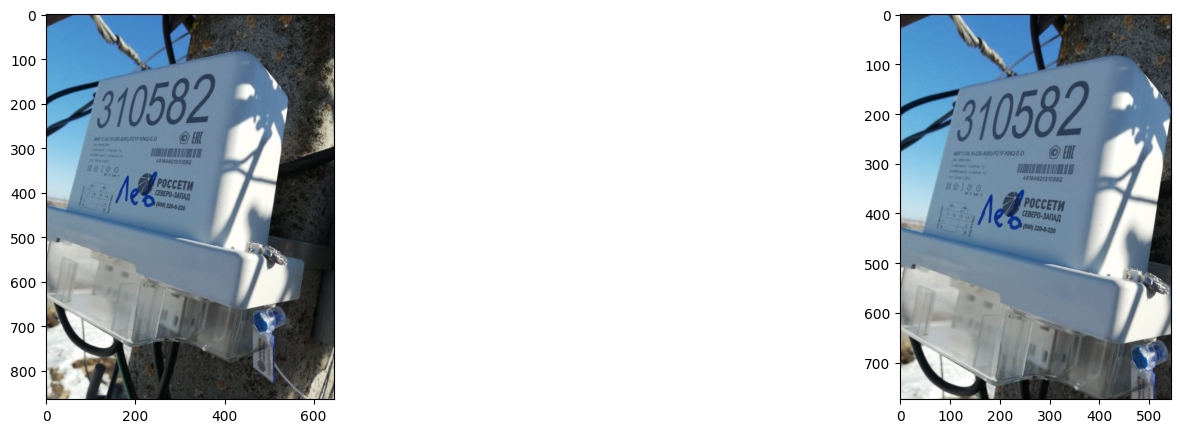

In [113]:
img = cv2.imread('./images/392502.png')

crop_meter(img)

fig, axes = plt.subplots(1, 2, figsize=(20, 5))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[1].imshow(cv2.cvtColor(crop_meter(img), cv2.COLOR_BGR2RGB))

In [114]:
import os

reader = easyocr.Reader(["ru"])

images_dir = "./images"
for filename in sorted(os.listdir(images_dir)):
    if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
        photo_id = os.path.splitext(filename)[0]
        img = cv2.imread(os.path.join(images_dir, filename))
        if img is not None:
            number = recognize_number(img, reader)
            print(f"{photo_id}: {number}")

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.
c:\Projects\data-analysis\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


371412: Не распознано
371414: 301729
374366: 710849
390245: 322894
392297: 334421
392303: 442974
392306: 443036
392310: 443282
392312: 443438
392318: 443451
392320: 443452
392324: 443455
392327: 443462
392331: 443472
392333: 443493
392498: 303349
392502: 310582
392507: 310831
392510: 310730
392514: Не распознано
392516: 364603
392520: 364862
392524: Не распознано
392525: 369085
407395: 374511
407397: 202228
407409: 387627
407413: 371412
407417: 375252
407429: 388558
